# Trabalho 05 — Classificação de Padrões com a Rede Neural **Adaline**

**Disciplina:** EL056 — Redes Neurais Artificiais · PPGEELT/UFU

---

### Enunciado

1. Treinar uma **Adaline** usando a base de dados **B2**.
2. **Plotar o erro quadrático total (EQT)** durante o treinamento.
3. **Realizar o teste** da rede neural treinada.

### Roteiro da apresentação

| # | Seção |
|---|-------|
| 1 | Fundamentação: o neurônio Adaline e a regra Delta |
| 2 | A base de dados B2 |
| 3 | Implementação |
| 4 | Treinamento e curva do erro quadrático total |
| 5 | Fronteira e regiões de decisão |
| 6 | Influência da taxa de aprendizagem |
| 7 | **Teste** da rede treinada |
| 8 | Adaline × Perceptron: margem e robustez a ruído |
| 9 | Conclusões |


## 1. Fundamentação: o neurônio Adaline

A **Adaline** (*ADAptive LInear NEuron*), proposta por Widrow e Hoff em 1960, é uma rede
de **camada única** com **um neurônio** e função de ativação **linear durante o treinamento**.

**Potencial de ativação** (com $x_0=-1$ associado ao limiar $\theta$):

$$u \;=\; \sum_{i=1}^{n} w_i x_i \;-\; \theta \;=\; \mathbf{W}^{\top}\mathbf{X}$$

**Saída em operação** (classificação bipolar):

$$y \;=\; \mathrm{sgn}(u) \;=\;
\begin{cases} +1, & u \ge 0\\[2pt] -1, & u < 0\end{cases}$$

### Regra Delta (Widrow–Hoff / LMS)

O treinamento minimiza o **erro quadrático** entre o **alvo** $d^{(p)}$ e o **potencial de
ativação** $u^{(p)}$ — e **não** entre o alvo e a saída pós-degrau, como faz o Perceptron:

$$E(\mathbf{W}) \;=\; \frac{1}{2}\sum_{p=1}^{P}\bigl(d^{(p)} - u^{(p)}\bigr)^{2}
\qquad\Longrightarrow\qquad
\nabla E \;=\; -\sum_{p=1}^{P}\bigl(d^{(p)} - u^{(p)}\bigr)\mathbf{X}^{(p)}$$

Aplicando a descida do gradiente, obtém-se a regra de ajuste:

$$\boxed{\;\mathbf{W} \leftarrow \mathbf{W} \;+\; \eta\,\bigl(d^{(p)} - u^{(p)}\bigr)\mathbf{X}^{(p)}\;}$$

**Métricas de erro monitoradas:**

$$\mathrm{EQT}(k)=\sum_{p=1}^{P}\bigl(d^{(p)}-u^{(p)}\bigr)^{2}
\qquad\qquad
\mathrm{EQM}(k)=\frac{1}{P}\,\mathrm{EQT}(k)$$

**Critério de parada:** $\;\bigl|\mathrm{EQM}(k)-\mathrm{EQM}(k-1)\bigr| \le \varepsilon$.

> **Consequência importante:** como $d\in\{-1,+1\}$ e $u$ é contínuo, o EQT **não converge
> para zero** mesmo com separação perfeita — ele converge para o mínimo da superfície
> quadrática, que é único (a superfície $E(\mathbf{W})$ é convexa).


## 2. A base de dados B2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adaline_b2 import (Adaline, Perceptron, carregar_base,
                        metricas, matriz_confusao, split_estratificado)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "grid.linestyle": ":",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "legend.frameon": False})
COR_A, COR_B, COR_L = "#1b6ca8", "#c0392b", "#2c3e50"

X, d, df = carregar_base("Basedados_B2.xlsx")
print(f"Amostras: {len(d)}   Atributos: {X.shape[1]}   "
      f"Classe +1: {int((d==1).sum())}   Classe -1: {int((d==-1).sum())}")
df.head(10)

Amostras: 20   Atributos: 2   Classe +1: 10   Classe -1: 10


,s1,s2,t
0,2.215,2.063,-1
1,0.224,1.586,1
2,0.294,0.651,1
3,2.327,2.932,-1
4,2.497,2.322,-1
5,0.169,1.943,1
6,1.274,2.428,-1
7,1.526,0.596,1
8,2.009,2.161,-1
9,1.759,0.342,1


In [2]:
df.describe().round(3)

,s1,s2,t
count,20.000,20.000,20.000
mean,1.459,1.555,0.000
std,0.847,0.797,1.026
min,0.169,0.090,-1.000
25%,0.730,0.914,-1.000
50%,1.556,1.620,0.000
75%,2.182,2.088,1.000
max,2.764,2.932,1.000


A base possui **20 amostras**, **2 atributos** contínuos ($s_1$, $s_2$) e um alvo bipolar
$t \in \{-1,+1\}$, perfeitamente balanceado (10/10). Como $s_1$ e $s_2$ já estão na mesma
faixa de valores (aproximadamente $[0,\,3]$), **não é necessário normalizar**.

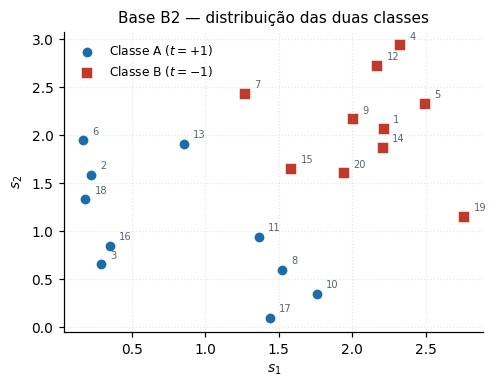

In [3]:
fig, ax = plt.subplots(figsize=(4.6, 3.6))
m = d == 1
ax.scatter(X[m,0], X[m,1], c=COR_A, marker="o", s=55, edgecolor="w", label="Classe A ($t=+1$)")
ax.scatter(X[~m,0], X[~m,1], c=COR_B, marker="s", s=55, edgecolor="w", label="Classe B ($t=-1$)")
for i,(a,b) in enumerate(X, start=1):
    ax.annotate(str(i), (a,b), textcoords="offset points", xytext=(6,4), fontsize=6.5, color="#566573")
ax.set_xlabel("$s_1$"); ax.set_ylabel("$s_2$"); ax.legend(fontsize=8)
ax.set_title("Base B2 — distribuição das duas classes", fontsize=10)
plt.tight_layout(); plt.show()

Visualmente as classes parecem **linearmente separáveis**, com os padrões #13
$(0{,}856;\,1{,}904)$ e #15 $(1{,}587;\,1{,}642)$ próximos da região de fronteira —
são eles que vão determinar a dificuldade do problema.

In [4]:
# Que regra teria gerado os rótulos? Ordenando pela soma dos atributos:
ordem = df.assign(soma=(df.s1+df.s2).round(3)).sort_values("soma")
lim_pos, lim_neg = ordem[ordem.t==1].soma.max(), ordem[ordem.t==-1].soma.min()
print(f"maior soma da classe +1 : {lim_pos}")
print(f"menor soma da classe -1 : {lim_neg}")
print(f"separação perfeita com folga de {lim_neg-lim_pos:.3f}  ->  regra ≈ (s1 + s2 < 3)")

maior soma da classe +1 : 2.76
menor soma da classe -1 : 3.229
separação perfeita com folga de 0.469  ->  regra ≈ (s1 + s2 < 3)


A coluna $t$ vem pronta no arquivo do professor — a rede precisa **descobrir** a regra que
a gerou. A ordenação acima sugere que o critério foi aproximadamente $s_1 + s_2 \lesssim 3$,
uma reta de inclinação $-45^\circ$. Guarde esse número: mais adiante comparamos com a
inclinação que a Adaline encontrou sozinha.

## 3. Implementação

O núcleo do algoritmo está em `adaline_b2.py`. O laço de treinamento é literalmente a
regra Delta aplicada padrão a padrão:

```python
while epocas < max_epocas:
    for xa, alvo in zip(Xa, d):
        u = xa @ self.w                    # ativação LINEAR
        self.w += self.eta * (alvo - u) * xa   # regra Delta
    epocas += 1
    eqm = mean((d - Xa @ self.w) ** 2)
    if abs(eqm - eqm_ant) <= self.epsilon:  # critério de parada
        break
    eqm_ant = eqm
```

A entrada é **aumentada** com $x_0 = -1$, de modo que `self.w = [θ, w1, w2]` e o limiar
é ajustado pela mesma regra dos demais pesos, sem tratamento especial.


## 4. Treinamento e curva do erro quadrático total

In [5]:
ETA, EPS, SEED = 0.0025, 1e-6, 42

net = Adaline(eta=ETA, epsilon=EPS, seed=SEED).fit(X, d)

print(f"Pesos iniciais : theta={net.w_inicial[0]:+.4f}  w1={net.w_inicial[1]:+.4f}  w2={net.w_inicial[2]:+.4f}")
print(f"Pesos finais   : theta={net.w[0]:+.4f}  w1={net.w[1]:+.4f}  w2={net.w[2]:+.4f}")
print(f"Épocas         : {net.epocas}   (convergiu = {net.convergiu})")
print(f"EQT inicial    : {net.hist_eqt[0]:.4f}")
print(f"EQT final      : {net.hist_eqt[-1]:.4f}    EQM final: {net.hist_eqm[-1]:.6f}")

Pesos iniciais : theta=+0.2740  w1=-0.0611  w2=+0.3586
Pesos finais   : theta=-2.0418  w1=-0.7492  w2=-0.6202
Épocas         : 704   (convergiu = True)
EQT inicial    : 28.2577
EQT final      : 3.7098    EQM final: 0.185491


### 4.1 Erro quadrático total durante o treinamento *(item 2 do enunciado)*

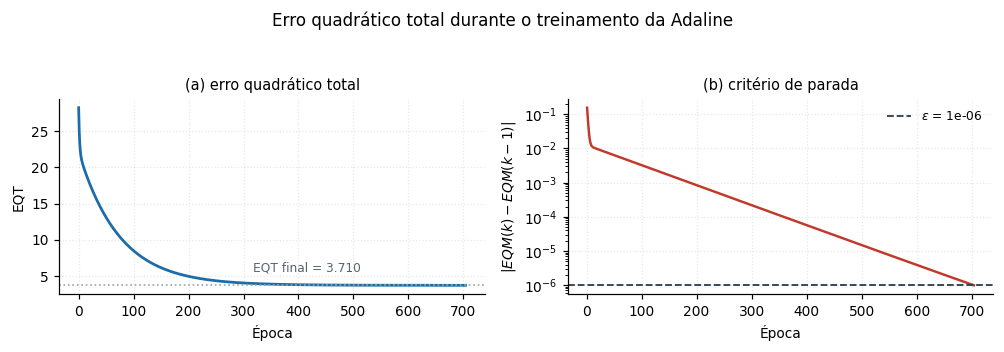

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(9.2, 3.2))
ep = np.arange(len(net.hist_eqt))

axs[0].plot(ep, net.hist_eqt, color=COR_A, lw=1.8)
axs[0].axhline(net.hist_eqt[-1], color="#95a5a6", ls=":", lw=1.1)
axs[0].annotate(f"EQT final = {net.hist_eqt[-1]:.3f}", xy=(net.epocas*.45, net.hist_eqt[-1]),
                xytext=(0,9), textcoords="offset points", fontsize=8, color="#566573")
axs[0].set_xlabel("Época"); axs[0].set_ylabel("EQT")
axs[0].set_title("(a) erro quadrático total", fontsize=9.5)

delta = np.abs(np.diff(net.hist_eqm))
axs[1].semilogy(np.arange(1, len(delta)+1), delta, color=COR_B, lw=1.6)
axs[1].axhline(EPS, color=COR_L, ls="--", lw=1.2, label=fr"$\varepsilon$ = {EPS:g}")
axs[1].set_xlabel("Época"); axs[1].set_ylabel(r"$|EQM(k)-EQM(k-1)|$")
axs[1].set_title("(b) critério de parada", fontsize=9.5); axs[1].legend(fontsize=8)

fig.suptitle("Erro quadrático total durante o treinamento da Adaline", fontsize=11)
plt.tight_layout(rect=(0,0,1,.93)); plt.show()

**Leitura do gráfico.** O EQT cai de $\approx 28{,}26$ para $\approx 3{,}71$ de forma
**monotonicamente decrescente e sem oscilações** — comportamento esperado de uma descida de
gradiente sobre uma superfície de erro **convexa**. Cerca de 90% da redução ocorre nas
primeiras 200 épocas; o restante é o refinamento fino que o critério
$|\Delta \mathrm{EQM}| \le \varepsilon$ interrompe na época 704.

O patamar em $\mathrm{EQT}\approx 3{,}71$ **não indica erro de classificação**: ele é o
resíduo natural entre os alvos bipolares e a saída linear $u$. Como se verá adiante, a
acurácia nesse ponto é de 100%.

### 4.2 Conferindo com a solução analítica

Como o custo é quadrático, esta base tem solução fechada pelas **equações normais** — dá
para calcular o mínimo exato sem iterar nada e verificar aonde a descida do gradiente
chegou.

In [7]:
Xa = np.c_[-np.ones(len(X)), X]
w_ot = np.linalg.pinv(Xa) @ d
eqm_ot = np.mean((d - Xa @ w_ot) ** 2)

print(f"Solução analítica  : theta={w_ot[0]:+.4f}  w1={w_ot[1]:+.4f}  w2={w_ot[2]:+.4f}   EQM={eqm_ot:.6f}")
print(f"Descida do gradiente: theta={net.w[0]:+.4f}  w1={net.w[1]:+.4f}  w2={net.w[2]:+.4f}   EQM={net.hist_eqm[-1]:.6f}")
print(f"\nDesvio no EQM: {abs(net.hist_eqm[-1]-eqm_ot)/eqm_ot*100:.3f}%")

Solução analítica  : theta=-2.0665  w1=-0.7504  w2=-0.6251   EQM=0.185234
Descida do gradiente: theta=-2.0418  w1=-0.7492  w2=-0.6202   EQM=0.185491

Desvio no EQM: 0.139%


A rede chegou a **0,139%** do mínimo teórico. Essa referência vai ser útil na próxima
seção: ela dá um padrão-ouro contra o qual medir o efeito da taxa de aprendizagem.

## 5. Fronteira e regiões de decisão

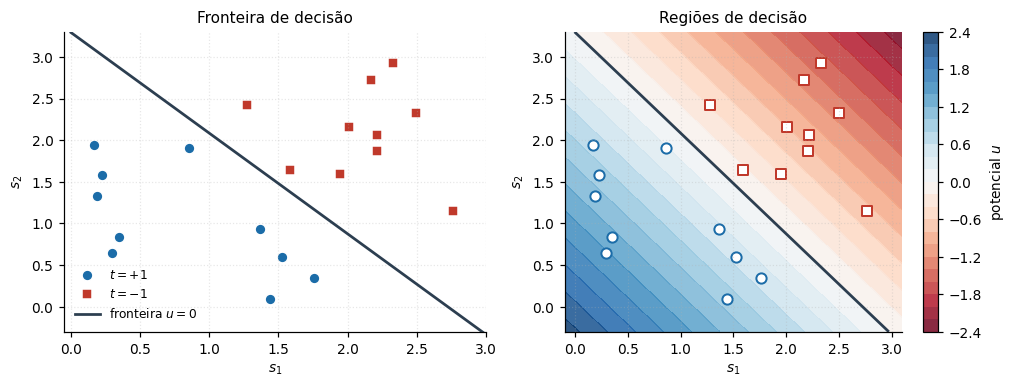

Fronteira implícita: -0.7492·s1 -0.6202·s2 +2.0418 = 0
Fronteira explícita: s2 = -1.2079·s1 +3.2920
Razão w1/w2 = 1.2079   (a regra geradora s1+s2<3 daria 1,0000)


In [8]:
g1, g2 = np.meshgrid(np.linspace(-.1, 3.1, 320), np.linspace(-.3, 3.3, 320))
U = net.potencial(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)

fig, axs = plt.subplots(1, 2, figsize=(9.4, 3.6))

s1 = np.linspace(0, 3, 200)
axs[0].scatter(X[m,0], X[m,1], c=COR_A, marker="o", s=50, edgecolor="w", label="$t=+1$")
axs[0].scatter(X[~m,0], X[~m,1], c=COR_B, marker="s", s=50, edgecolor="w", label="$t=-1$")
axs[0].plot(s1, net.reta_separacao(s1), color=COR_L, lw=1.8, label="fronteira $u=0$")
axs[0].set_xlim(-.05,3); axs[0].set_ylim(-.3,3.3)
axs[0].set_xlabel("$s_1$"); axs[0].set_ylabel("$s_2$"); axs[0].legend(fontsize=8)
axs[0].set_title("Fronteira de decisão", fontsize=10)

cf = axs[1].contourf(g1, g2, U, levels=24, cmap="RdBu", alpha=.85)
axs[1].contour(g1, g2, U, levels=[0], colors=[COR_L], linewidths=1.8)
plt.colorbar(cf, ax=axs[1], label="potencial $u$")
axs[1].scatter(X[m,0], X[m,1], c="w", edgecolor=COR_A, marker="o", s=45, linewidth=1.3)
axs[1].scatter(X[~m,0], X[~m,1], c="w", edgecolor=COR_B, marker="s", s=45, linewidth=1.3)
axs[1].set_xlabel("$s_1$"); axs[1].set_ylabel("$s_2$")
axs[1].set_title("Regiões de decisão", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Fronteira implícita: {net.w[1]:+.4f}·s1 {net.w[2]:+.4f}·s2 {-net.w[0]:+.4f} = 0")
print(f"Fronteira explícita: s2 = {-net.w[1]/net.w[2]:+.4f}·s1 {net.w[0]/net.w[2]:+.4f}")
print(f"Razão w1/w2 = {net.w[1]/net.w[2]:.4f}   (a regra geradora s1+s2<3 daria 1,0000)")

O painel da direita mostra o que o Perceptron descarta: o **valor** de $u$, e não apenas
o seu sinal. As faixas de cor são retas paralelas porque $u$ é função linear das entradas.

Note a razão $w_1/w_2 = 1{,}208$ contra o valor $1{,}0$ da regra que provavelmente gerou os
rótulos. Não é erro: o LMS posiciona o hiperplano minimizando o desvio de $u$ em **todos**
os pontos, e qualquer reta dentro da faixa vazia entre as classes acerta 100%.

In [9]:
tab = df.copy()
tab["u"] = np.round(net.potencial(X), 4)
tab["y = sgn(u)"] = net.predict(X).astype(int)
tab["acertou"] = tab["y = sgn(u)"] == tab["t"]
tab.index = np.arange(1, len(tab)+1)
print(f"Acurácia sobre os 20 padrões de treinamento: "
      f"{metricas(d, net.predict(X))['acuracia']*100:.1f}%")
tab

Acurácia sobre os 20 padrões de treinamento: 100.0%


,s1,s2,t,u,y = sgn(u),acertou
1,2.215,2.063,-1,-0.8972,-1,True
2,0.224,1.586,1,0.8903,1,True
3,0.294,0.651,1,1.4178,1,True
4,2.327,2.932,-1,-1.5201,-1,True
5,2.497,2.322,-1,-1.2691,-1,True
6,0.169,1.943,1,0.7101,1,True
7,1.274,2.428,-1,-0.4186,-1,True
8,1.526,0.596,1,0.5289,1,True
9,2.009,2.161,-1,-0.8037,-1,True
10,1.759,0.342,1,0.5118,1,True


## 6. Influência da taxa de aprendizagem $\eta$

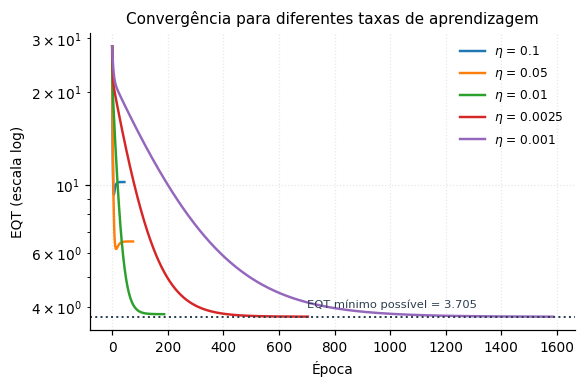

,eta,épocas,EQT final,EQM final,acurácia (%)
0,0.1000,44,10.1977,0.509886,95.0
1,0.0500,75,6.5270,0.326348,95.0
2,0.0100,187,3.7796,0.188979,100.0
3,0.0025,704,3.7098,0.185491,100.0
4,0.0010,1586,3.7090,0.185450,100.0


In [10]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
linhas = []
for e in (0.1, 0.05, 0.01, 0.0025, 0.001):
    mm = Adaline(eta=e, epsilon=EPS, seed=SEED).fit(X, d)
    ax.semilogy(np.arange(len(mm.hist_eqt)), mm.hist_eqt, lw=1.6, label=fr"$\eta$ = {e:g}")
    linhas.append({"eta": e, "épocas": mm.epocas, "EQT final": round(mm.hist_eqt[-1], 4),
                   "EQM final": round(mm.hist_eqm[-1], 6),
                   "acurácia (%)": round(metricas(d, mm.predict(X))["acuracia"]*100, 1)})
ax.axhline(eqm_ot*len(d), color=COR_L, ls=":", lw=1.3)
ax.annotate(f"EQT mínimo possível = {eqm_ot*len(d):.3f}", xy=(700, eqm_ot*len(d)),
            xytext=(0,6), textcoords="offset points", fontsize=7.5, color=COR_L)
ax.set_xlabel("Época"); ax.set_ylabel("EQT (escala log)"); ax.legend(fontsize=8)
ax.set_title("Convergência para diferentes taxas de aprendizagem", fontsize=10)
plt.tight_layout(); plt.show()

pd.DataFrame(linhas)

### 6.1 O que realmente acontece com $\eta$ grande

A explicação intuitiva seria "o passo é grande demais e o algoritmo diverge". **Não é o
caso.** O critério de estabilidade do LMS é $\eta < 2/\lambda_{\max}$, onde
$\lambda_{\max}$ é o maior autovalor da matriz de autocorrelação das entradas.

In [11]:
R = Xa.T @ Xa / len(X)
ev = np.linalg.eigvalsh(R)
print("Autovalores de R:", np.round(ev, 4))
print(f"Limite de estabilidade: eta < 2/{ev.max():.4f} = {2/ev.max():.4f}")
print("\nTodos os valores testados (0,001 a 0,1) estão DENTRO da região estável.\n")

for e in (0.1, 0.05, 0.0025):
    for sd in (42, 7):
        mm = Adaline(eta=e, epsilon=EPS, seed=sd).fit(X, d)
        print(f"eta={e:<7g} seed={sd:<3d} -> w = {np.round(mm.w,4)}   EQM = {mm.hist_eqm[-1]:.6f}")

Autovalores de R: [0.1342 0.4386 6.2583]
Limite de estabilidade: eta < 2/6.2583 = 0.3196

Todos os valores testados (0,001 a 0,1) estão DENTRO da região estável.

eta=0.1     seed=42  -> w = [-2.3073 -0.8613 -0.9801]   EQM = 0.509886
eta=0.1     seed=7   -> w = [-2.3073 -0.8613 -0.9801]   EQM = 0.509886
eta=0.05    seed=42  -> w = [-2.0934 -0.8192 -0.7962]   EQM = 0.326348
eta=0.05    seed=7   -> w = [-2.0934 -0.8192 -0.7962]   EQM = 0.326348
eta=0.0025  seed=42  -> w = [-2.0418 -0.7492 -0.6202]   EQM = 0.185491
eta=0.0025  seed=7   -> w = [-2.0418 -0.7492 -0.6202]   EQM = 0.185491


**O fenômeno é outro: desajuste (*misadjustment*).** No treinamento sequencial, cada padrão
puxa os pesos para o seu lado dentro da mesma época. Com passo grande, cada puxão é forte, e
a composição das 20 atualizações tem um **ponto fixo deslocado** em relação ao mínimo
verdadeiro — o desvio é proporcional a $\eta$.

A evidência está na saída acima: com $\eta = 0{,}1$, sementes diferentes convergem para
pesos **idênticos**. Não é ruído nem oscilação aleatória — o algoritmo converge de verdade,
só que para o lugar errado ($\mathrm{EQM} = 0{,}5099$ contra o mínimo de $0{,}1852$).

O critério de parada, portanto, **não falhou**: a variação entre épocas realmente foi a zero.
O que compromete o resultado é a própria localização do ponto fixo.

In [12]:
mm = Adaline(eta=0.1, epsilon=EPS, seed=SEED).fit(X, d)
y10 = mm.predict(X)
ruim = np.where(y10 != d)[0]
for i in ruim:
    print(f"padrão #{i+1}  {X[i]}  t={int(d[i]):+d}  y={int(y10[i]):+d}  "
          f"u={float(mm.potencial(X[i:i+1])[0]):+.4f}")
print(f"\nAcurácia com eta=0,1: {metricas(d, y10)['acuracia']*100:.1f}%  "
      f"(o desvio da fronteira deixa 1 padrão do lado errado)")

padrão #13  [0.856 1.904]  t=+1  y=-1  u=-0.2961

Acurácia com eta=0,1: 95.0%  (o desvio da fronteira deixa 1 padrão do lado errado)


Adotou-se $\eta = 0{,}0025$: entre ele e $0{,}001$ o EQM praticamente não melhora
($0{,}185491$ contra $0{,}185450$), mas o custo dobra — sinal de retorno decrescente.

## 7. Teste da rede treinada *(item 3 do enunciado)*

> **A rede do trabalho é a treinada com as 20 amostras**, apresentada na Seção 4. Como a base
> B2 não traz um conjunto de teste separado, os protocolos a seguir **retreinam** a rede em
> subconjuntos, com o único propósito de estimar a capacidade de generalização. Avaliar a
> rede apenas sobre os padrões que ela usou para ajustar os pesos daria uma medida otimista.

### 7.1 Holdout estratificado 70/30 (14 treino / 6 teste)

In [13]:
Xtr, dtr, Xte, dte, itr, ite = split_estratificado(X, d, 0.7, seed=0)
h = Adaline(eta=ETA, epsilon=EPS, seed=SEED).fit(Xtr, dtr)
y = h.predict(Xte)

print(f"Treinada em {len(dtr)} padrões  |  {h.epocas} épocas  |  "
      f"theta={h.w[0]:+.4f}  w1={h.w[1]:+.4f}  w2={h.w[2]:+.4f}\n")
pd.DataFrame({"amostra": ite+1, "s1": Xte[:,0], "s2": Xte[:,1],
              "t (desejado)": dte.astype(int),
              "u": np.round(h.potencial(Xte), 4),
              "y (obtido)": y.astype(int),
              "acertou": y == dte})

Treinada em 14 padrões  |  1176 épocas  |  theta=-2.3313  w1=-0.8215  w2=-0.7357



,amostra,s1,s2,t (desejado),u,y (obtido),acertou
0,11,1.367,0.938,1,0.5181,1,True
1,3,0.294,0.651,1,1.6108,1,True
2,1,2.215,2.063,-1,-1.0062,-1,True
3,19,2.764,1.149,-1,-0.7847,-1,True
4,4,2.327,2.932,-1,-1.7376,-1,True
5,16,0.350,0.840,1,1.4257,1,True


In [14]:
vp, fn, fp, vn = matriz_confusao(dte, y)
print("Matriz de confusão (conjunto de teste)")
print(pd.DataFrame([[vp, fn],[fp, vn]],
                   index=["real +1","real -1"], columns=["previsto +1","previsto -1"]))
mt = metricas(dte, y)
print(f"\nAcurácia {mt['acuracia']*100:.1f}%  |  Precisão {mt['precisao']*100:.1f}%  "
      f"|  Revocação {mt['revocacao']*100:.1f}%  |  F1 {mt['f1']*100:.1f}%")

Matriz de confusão (conjunto de teste)
         previsto +1  previsto -1
real +1            3            0
real -1            0            3

Acurácia 100.0%  |  Precisão 100.0%  |  Revocação 100.0%  |  F1 100.0%


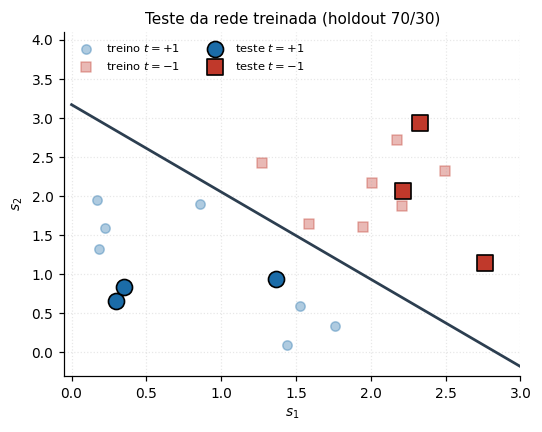

In [15]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
ax.scatter(Xtr[dtr==1,0],  Xtr[dtr==1,1],  c=COR_A, marker="o", s=38, alpha=.35, label="treino $t=+1$")
ax.scatter(Xtr[dtr==-1,0], Xtr[dtr==-1,1], c=COR_B, marker="s", s=38, alpha=.35, label="treino $t=-1$")
ok = y == dte
ax.scatter(Xte[ok&(dte==1),0],  Xte[ok&(dte==1),1],  c=COR_A, marker="o", s=110,
           edgecolor="k", lw=1.1, label="teste $t=+1$", zorder=4)
ax.scatter(Xte[ok&(dte==-1),0], Xte[ok&(dte==-1),1], c=COR_B, marker="s", s=110,
           edgecolor="k", lw=1.1, label="teste $t=-1$", zorder=4)
if (~ok).any():
    ax.scatter(Xte[~ok,0], Xte[~ok,1], facecolor="none", edgecolor="k", s=200, lw=1.7,
               label="erro", zorder=5)
ax.plot(np.linspace(0,3,200), h.reta_separacao(np.linspace(0,3,200)), color=COR_L, lw=1.8)
ax.set_xlim(-.05,3); ax.set_ylim(-.3,4.1)
ax.set_xlabel("$s_1$"); ax.set_ylabel("$s_2$"); ax.legend(fontsize=7.5, ncol=2, loc="upper left")
ax.set_title("Teste da rede treinada (holdout 70/30)", fontsize=10)
plt.tight_layout(); plt.show()

### 7.2 Repetição do holdout em 10 partições distintas

Uma única partição é frágil: com 6 amostras de teste, cada erro vale 16,7% da acurácia.

In [16]:
linhas = []
for s in range(10):
    a, b, c_, e_, *_ = split_estratificado(X, d, 0.7, seed=s)
    mm = Adaline(eta=ETA, epsilon=EPS, seed=SEED).fit(a, b)
    linhas.append({"rodada": s+1, "épocas": mm.epocas,
                   "acurácia treino (%)": metricas(b, mm.predict(a))["acuracia"]*100,
                   "acurácia teste (%)":  metricas(e_, mm.predict(c_))["acuracia"]*100})
res = pd.DataFrame(linhas)
acc = res["acurácia teste (%)"]
print(f"Acurácia média de teste: {acc.mean():.1f}% ± {acc.std(ddof=1):.1f}%  "
      f"(mín {acc.min():.1f}%, máx {acc.max():.1f}%)")
res

Acurácia média de teste: 98.3% ± 5.3%  (mín 83.3%, máx 100.0%)


,rodada,épocas,acurácia treino (%),acurácia teste (%)
0,1,1176,100.0,100.000000
1,2,850,100.0,100.000000
2,3,1102,100.0,100.000000
3,4,978,100.0,100.000000
4,5,1261,100.0,100.000000
5,6,864,100.0,100.000000
6,7,995,100.0,100.000000
7,8,944,100.0,100.000000
8,9,998,100.0,83.333333
9,10,1008,100.0,100.000000


### 7.3 Validação cruzada *leave-one-out* (20 partições)

In [17]:
acertos, erros = 0, []
for i in range(len(d)):
    mask = np.ones(len(d), bool); mask[i] = False
    mm = Adaline(eta=ETA, epsilon=EPS, seed=SEED).fit(X[mask], d[mask])
    if mm.predict(X[i:i+1])[0] == d[i]:
        acertos += 1
    else:
        erros.append(i+1)
print(f"Leave-one-out: {acertos}/{len(d)} acertos  =  {acertos/len(d)*100:.1f}%")
print("Amostras classificadas incorretamente:", erros if erros else "nenhuma")

Leave-one-out: 20/20 acertos  =  100.0%
Amostras classificadas incorretamente: nenhuma


O contraste entre 7.2 e 7.3 é informativo: com 14 amostras a fronteira ainda se desloca o
suficiente para errar o padrão #13; com 19, já se estabiliza. A base está no limite do que o
problema exige.

### 7.4 Operação sobre padrões inéditos

In [18]:
novos = np.array([[0.50,0.50],[0.90,1.10],[1.50,1.20],
                  [1.60,1.90],[2.40,2.40],[2.90,0.80]])
pd.DataFrame({"s1": novos[:,0], "s2": novos[:,1],
              "u": np.round(net.potencial(novos), 4),
              "y = sgn(u)": net.predict(novos).astype(int),
              "classe": ["A" if v>0 else "B" for v in net.predict(novos)]})

,s1,s2,u,y = sgn(u),classe
0,0.5,0.5,1.3571,1,A
1,0.9,1.1,0.6853,1,A
2,1.5,1.2,0.1737,1,A
3,1.6,1.9,-0.3353,-1,B
4,2.4,2.4,-1.2448,-1,B
5,2.9,0.8,-0.6271,-1,B


O valor de $u$ é interpretável: quanto **maior o módulo**, mais distante da fronteira e
mais **confiante** a classificação. O padrão $(1{,}50;\,1{,}20)$, com $u = 0{,}17$, está na
zona de incerteza — exatamente a região onde os erros ocorrem.

## 8. Adaline × Perceptron: margem e robustez a ruído

Adaline    :  704 épocas | acurácia 100% | margem mínima = 0.1703 (padrão #15)
Perceptron :   23 épocas | acurácia 100% | margem mínima = 0.0018 (padrão #13)
Ângulo entre as duas fronteiras: 16.92°   |   razão entre margens: 97x


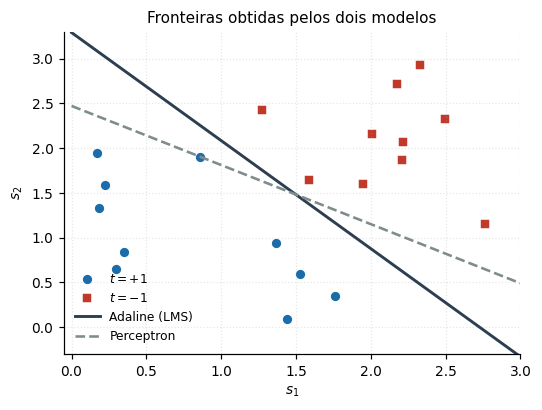

In [19]:
perc = Perceptron(eta=ETA, seed=SEED).fit(X, d)

def margem(w):
    return (np.c_[-np.ones(len(X)), X] @ w) / np.linalg.norm(w[1:])

ma_v, mp_v = margem(net.w), margem(perc.w)
ma, mp = np.abs(ma_v).min(), np.abs(mp_v).min()
va = net.w[1:]/np.linalg.norm(net.w[1:]); vp = perc.w[1:]/np.linalg.norm(perc.w[1:])
ang = np.degrees(np.arccos(np.clip(va@vp, -1, 1)))

print(f"Adaline    : {net.epocas:4d} épocas | acurácia 100% | margem mínima = {ma:.4f} (padrão #{np.abs(ma_v).argmin()+1})")
print(f"Perceptron : {perc.epocas:4d} épocas | acurácia 100% | margem mínima = {mp:.4f} (padrão #{np.abs(mp_v).argmin()+1})")
print(f"Ângulo entre as duas fronteiras: {ang:.2f}°   |   razão entre margens: {ma/mp:.0f}x")

fig, ax = plt.subplots(figsize=(5.0, 3.8))
s1 = np.linspace(0, 3, 200)
ax.scatter(X[m,0], X[m,1], c=COR_A, marker="o", s=50, edgecolor="w", label="$t=+1$")
ax.scatter(X[~m,0], X[~m,1], c=COR_B, marker="s", s=50, edgecolor="w", label="$t=-1$")
ax.plot(s1, net.reta_separacao(s1),  color=COR_L,    lw=1.9, label="Adaline (LMS)")
ax.plot(s1, perc.reta_separacao(s1), color="#7f8c8d", lw=1.7, ls="--", label="Perceptron")
ax.set_xlim(-.05,3); ax.set_ylim(-.3,3.3)
ax.set_xlabel("$s_1$"); ax.set_ylabel("$s_2$"); ax.legend(fontsize=8)
ax.set_title("Fronteiras obtidas pelos dois modelos", fontsize=10)
plt.tight_layout(); plt.show()

O Perceptron converge em bem menos épocas, porque **para assim que não há mais erros de
classificação** — a primeira fronteira válida encontrada é aceita, e ela passa rente ao
padrão #13. A Adaline continua ajustando os pesos mesmo sem erros, pois minimiza o erro sobre
o potencial de ativação, e afasta o hiperplano dos padrões.

Até aqui isso é um argumento geométrico. A próxima célula o transforma em experimento.

### 8.1 Degradação sob ruído

As duas redes já treinadas (com dados limpos) recebem entradas corrompidas por ruído
gaussiano de desvio $\sigma$ crescente, 200 repetições por nível. Se a margem importa, a
fronteira do Perceptron deve falhar antes.

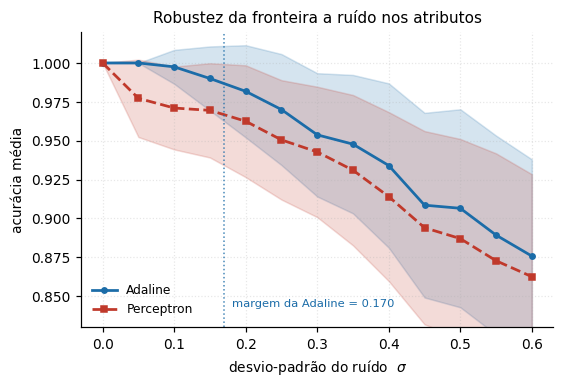

,sigma,Adaline (%),Perceptron (%),diferença (p.p.)
0,0.00,100.00,100.00,0.00
1,0.05,100.00,97.72,2.28
2,0.10,99.75,97.10,2.65
3,0.15,99.00,96.95,2.05
4,0.20,98.17,96.25,1.92
5,0.25,97.00,95.05,1.95
6,0.30,95.37,94.28,1.10
7,0.35,94.78,93.10,1.68


In [20]:
rng = np.random.default_rng(SEED)
sigmas = np.linspace(0, 0.60, 13)
med_a, dp_a, med_p, dp_p = [], [], [], []
for sg in sigmas:
    aa, pp = [], []
    for _ in range(200):
        Xr = X + rng.normal(0, sg, X.shape) if sg > 0 else X
        aa.append(metricas(d, net.predict(Xr))["acuracia"])
        pp.append(metricas(d, perc.predict(Xr))["acuracia"])
    med_a.append(np.mean(aa)); dp_a.append(np.std(aa))
    med_p.append(np.mean(pp)); dp_p.append(np.std(pp))
med_a, dp_a = np.array(med_a), np.array(dp_a)
med_p, dp_p = np.array(med_p), np.array(dp_p)

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(sigmas, med_a, color=COR_A, lw=1.8, marker="o", ms=3.5, label="Adaline")
ax.fill_between(sigmas, med_a-dp_a, med_a+dp_a, color=COR_A, alpha=.18)
ax.plot(sigmas, med_p, color=COR_B, lw=1.8, ls="--", marker="s", ms=3.5, label="Perceptron")
ax.fill_between(sigmas, med_p-dp_p, med_p+dp_p, color=COR_B, alpha=.18)
ax.axvline(ma, color=COR_A, lw=1.0, ls=":", alpha=.8)
ax.annotate(f"margem da Adaline = {ma:.3f}", xy=(ma, 0.845), xytext=(5,0),
            textcoords="offset points", fontsize=7.5, color=COR_A, va="center")
ax.set_xlabel("desvio-padrão do ruído  $\\sigma$"); ax.set_ylabel("acurácia média")
ax.set_ylim(0.83, 1.02); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Robustez da fronteira a ruído nos atributos", fontsize=10)
plt.tight_layout(); plt.show()

pd.DataFrame({"sigma": np.round(sigmas,2),
              "Adaline (%)": np.round(med_a*100,2),
              "Perceptron (%)": np.round(med_p*100,2),
              "diferença (p.p.)": np.round((med_a-med_p)*100,2)}).head(8)

**O resultado confirma a previsão, com uma nuance honesta.** Já em $\sigma = 0{,}05$ —
ruído praticamente imperceptível — a Adaline continua em 100% enquanto o Perceptron cai para
97,7%. É exatamente o padrão #13 sendo invertido: a fronteira do Perceptron passa a 0,0018
dele, então qualquer perturbação o joga para o outro lado em cerca de metade das repetições
($1/20 = 5\%$, metade das vezes $\approx 2{,}5$ p.p.).

A vantagem se mantém em toda a faixa testada, entre 1 e 2,6 pontos percentuais. Ela **não**
cresce indefinidamente porque, com $\sigma$ grande, o ruído passa a afetar padrões distantes
da fronteira também, e aí as duas redes sofrem igualmente. A margem protege contra
perturbações **pequenas**, que é justamente o regime de interesse prático.

In [21]:
ws = []
for s in range(20):
    mm = Adaline(eta=ETA, epsilon=EPS, seed=s).fit(X, d)
    ws.append([mm.w[0], mm.w[1], mm.w[2], mm.epocas, mm.hist_eqm[-1]])
ws = pd.DataFrame(ws, columns=["theta","w1","w2","épocas","EQM final"])
print("20 inicializações aleatórias distintas dos pesos:")
ws.agg(["mean","std"]).round(6)

20 inicializações aleatórias distintas dos pesos:


,theta,w1,w2,épocas,EQM final
mean,-2.041771,-0.749195,-0.620214,686.850000,0.185492
std,0.000042,0.000010,0.000014,17.786083,0.000000


Os pesos finais são **praticamente idênticos** em todas as inicializações
(desvio-padrão da ordem de $10^{-5}$), confirmando na prática que a superfície de erro da
Adaline é convexa e possui **mínimo global único** — diferentemente do Perceptron, cuja
solução depende da inicialização e da ordem de apresentação dos padrões.

## 9. Conclusões

1. A Adaline treinada pela regra Delta **classificou corretamente os 20 padrões da base B2**,
   confirmando que o problema é linearmente separável. Os pesos obtidos ficaram a **0,139%**
   do mínimo analítico dado pelas equações normais.
2. O **EQT decresceu monotonicamente** de 28,26 para 3,71 em 704 épocas; o resíduo não nulo é
   inerente ao uso de alvos bipolares com ativação linear, e não indica erro de classificação.
3. O teste por **holdout estratificado** (98,3% ± 5,3% em 10 rodadas) e por
   **leave-one-out** (100%) indica boa generalização; o único erro envolveu o padrão #13,
   situado sobre a região de fronteira.
4. Taxas de aprendizagem elevadas **não divergem** — todas ficaram dentro do limite
   $\eta < 0{,}3196$ — mas sofrem **desajuste**: convergem para um ponto fixo deslocado do
   mínimo, degradando a acurácia para 95%.
5. Comparada ao Perceptron, a Adaline exige mais épocas, mas entrega uma fronteira com
   **margem 97× maior**, solução **reprodutível** e, no experimento de ruído,
   **1 a 2,6 pontos percentuais** de acurácia a mais em toda a faixa testada.

### Referências

- WIDROW, B.; HOFF, M. E. *Adaptive switching circuits*. IRE WESCON Convention Record, 1960.
- WIDROW, B.; LEHR, M. A. *30 years of adaptive neural networks*. Proceedings of the IEEE,
  v. 78, n. 9, 1990.
- SILVA, I. N.; SPATTI, D. H.; FLAUZINO, R. A. *Redes Neurais Artificiais para Engenharia e
  Ciências Aplicadas*. 2. ed. São Paulo: Artliber, 2016.
- HAYKIN, S. *Redes Neurais: Princípios e Prática*. 2. ed. Porto Alegre: Bookman, 2001.
